In [104]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
import importlib
from universe import candidates, correlation, pca
from evaluation import plot
importlib.reload(correlation)

returns, tickers = candidates.load_data()
filtered_returns, filtered_tickers = candidates.filter_annualized()

returns = returns[filtered_tickers]
tickers = filtered_tickers

[*********************100%***********************]  28 of 28 completed
[*********************100%***********************]  28 of 28 completed


In [106]:
loadings, p_comp = pca.fit_pca(returns, tickers)
matrix = correlation.corr_matrix(returns)

In [107]:
from evaluation import metrics

for ticker in tickers:
    print(f'{ticker}: {metrics.calculate_annualized_returns(filtered_returns[ticker], start = '2010-01-01', end = '2018-01-01')}')

QQQ: 0.1762450068993573
IWM: 0.13106167846492056
IJH: 0.14147533949297575
VUG: 0.14219928776328028
VTV: 0.13136399552030786
XLK: 0.15405067105252868
XLF: 0.1306093288739112
XLV: 0.1471227104455377
XLU: 0.10893449726366211
XLI: 0.15412507950560594
XLB: 0.0993208437761739
XLP: 0.1291812724382777
XLY: 0.17780533863873704
EFA: 0.058108519174778106
VGK: 0.059105800712443646
EWJ: 0.06844843811450563
IBB: 0.18650015556224697
VNQ: 0.12492319740881785
SOXX: 0.17879577513872658


In [108]:
final_asset_returns, final_tickers = candidates.final_asset_drift()

for ticker in final_tickers:
    print(f'{ticker}: {metrics.calculate_annualized_returns(final_asset_returns[ticker])}')

[*********************100%***********************]  7 of 7 completed

VTV: 0.08573066376973615
XLU: 0.07256031076350244
XLV: 0.10293934991432763
EWJ: 0.030655446288939014
IBB: 0.10064652913305605
SPY: 0.1064274380723611
GLD: 0.06360849954829151


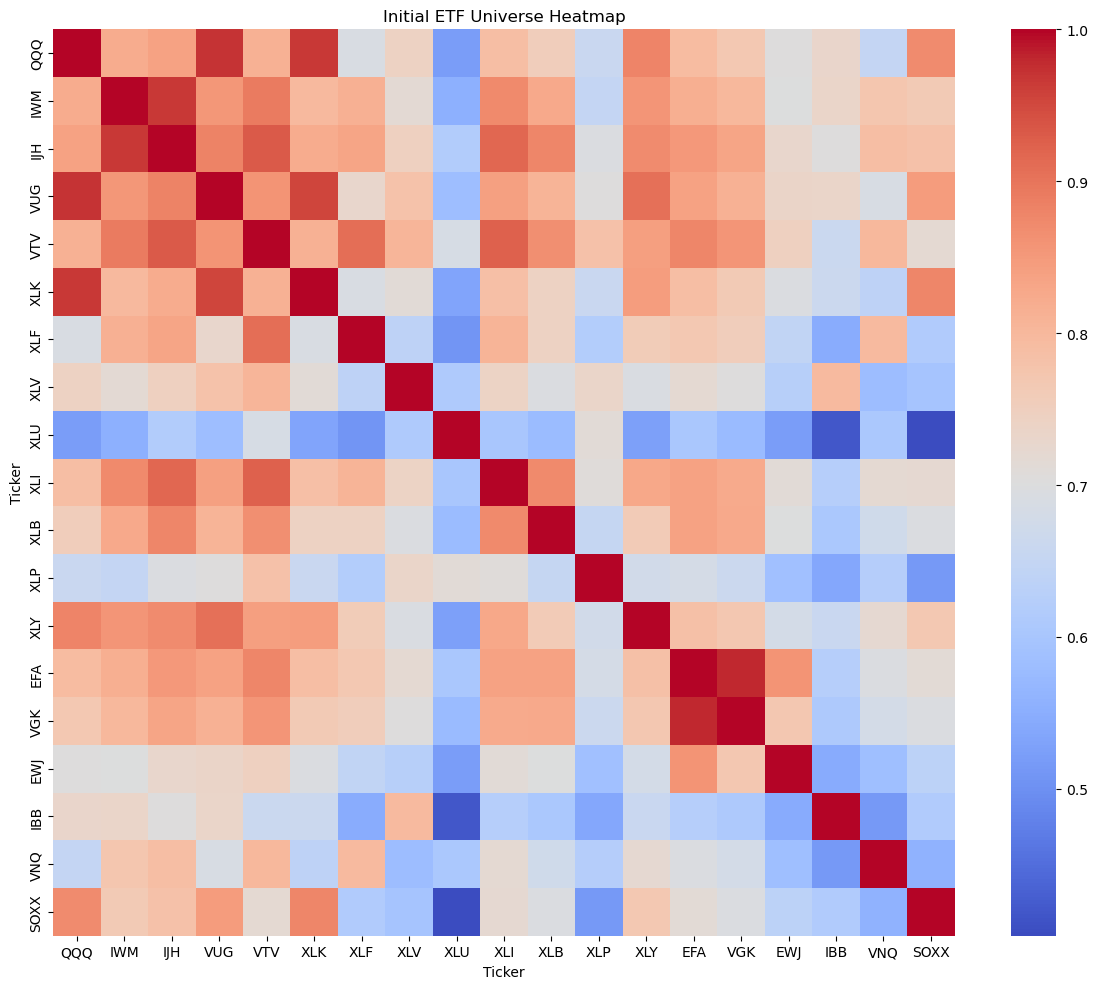

In [109]:
import os

heatmap = plot.plot_correlation_heatmap(matrix)
os.makedirs('results/universe_selection', exist_ok = True)
heatmap.savefig('results/universe_selection/correlation_heatmap.png')

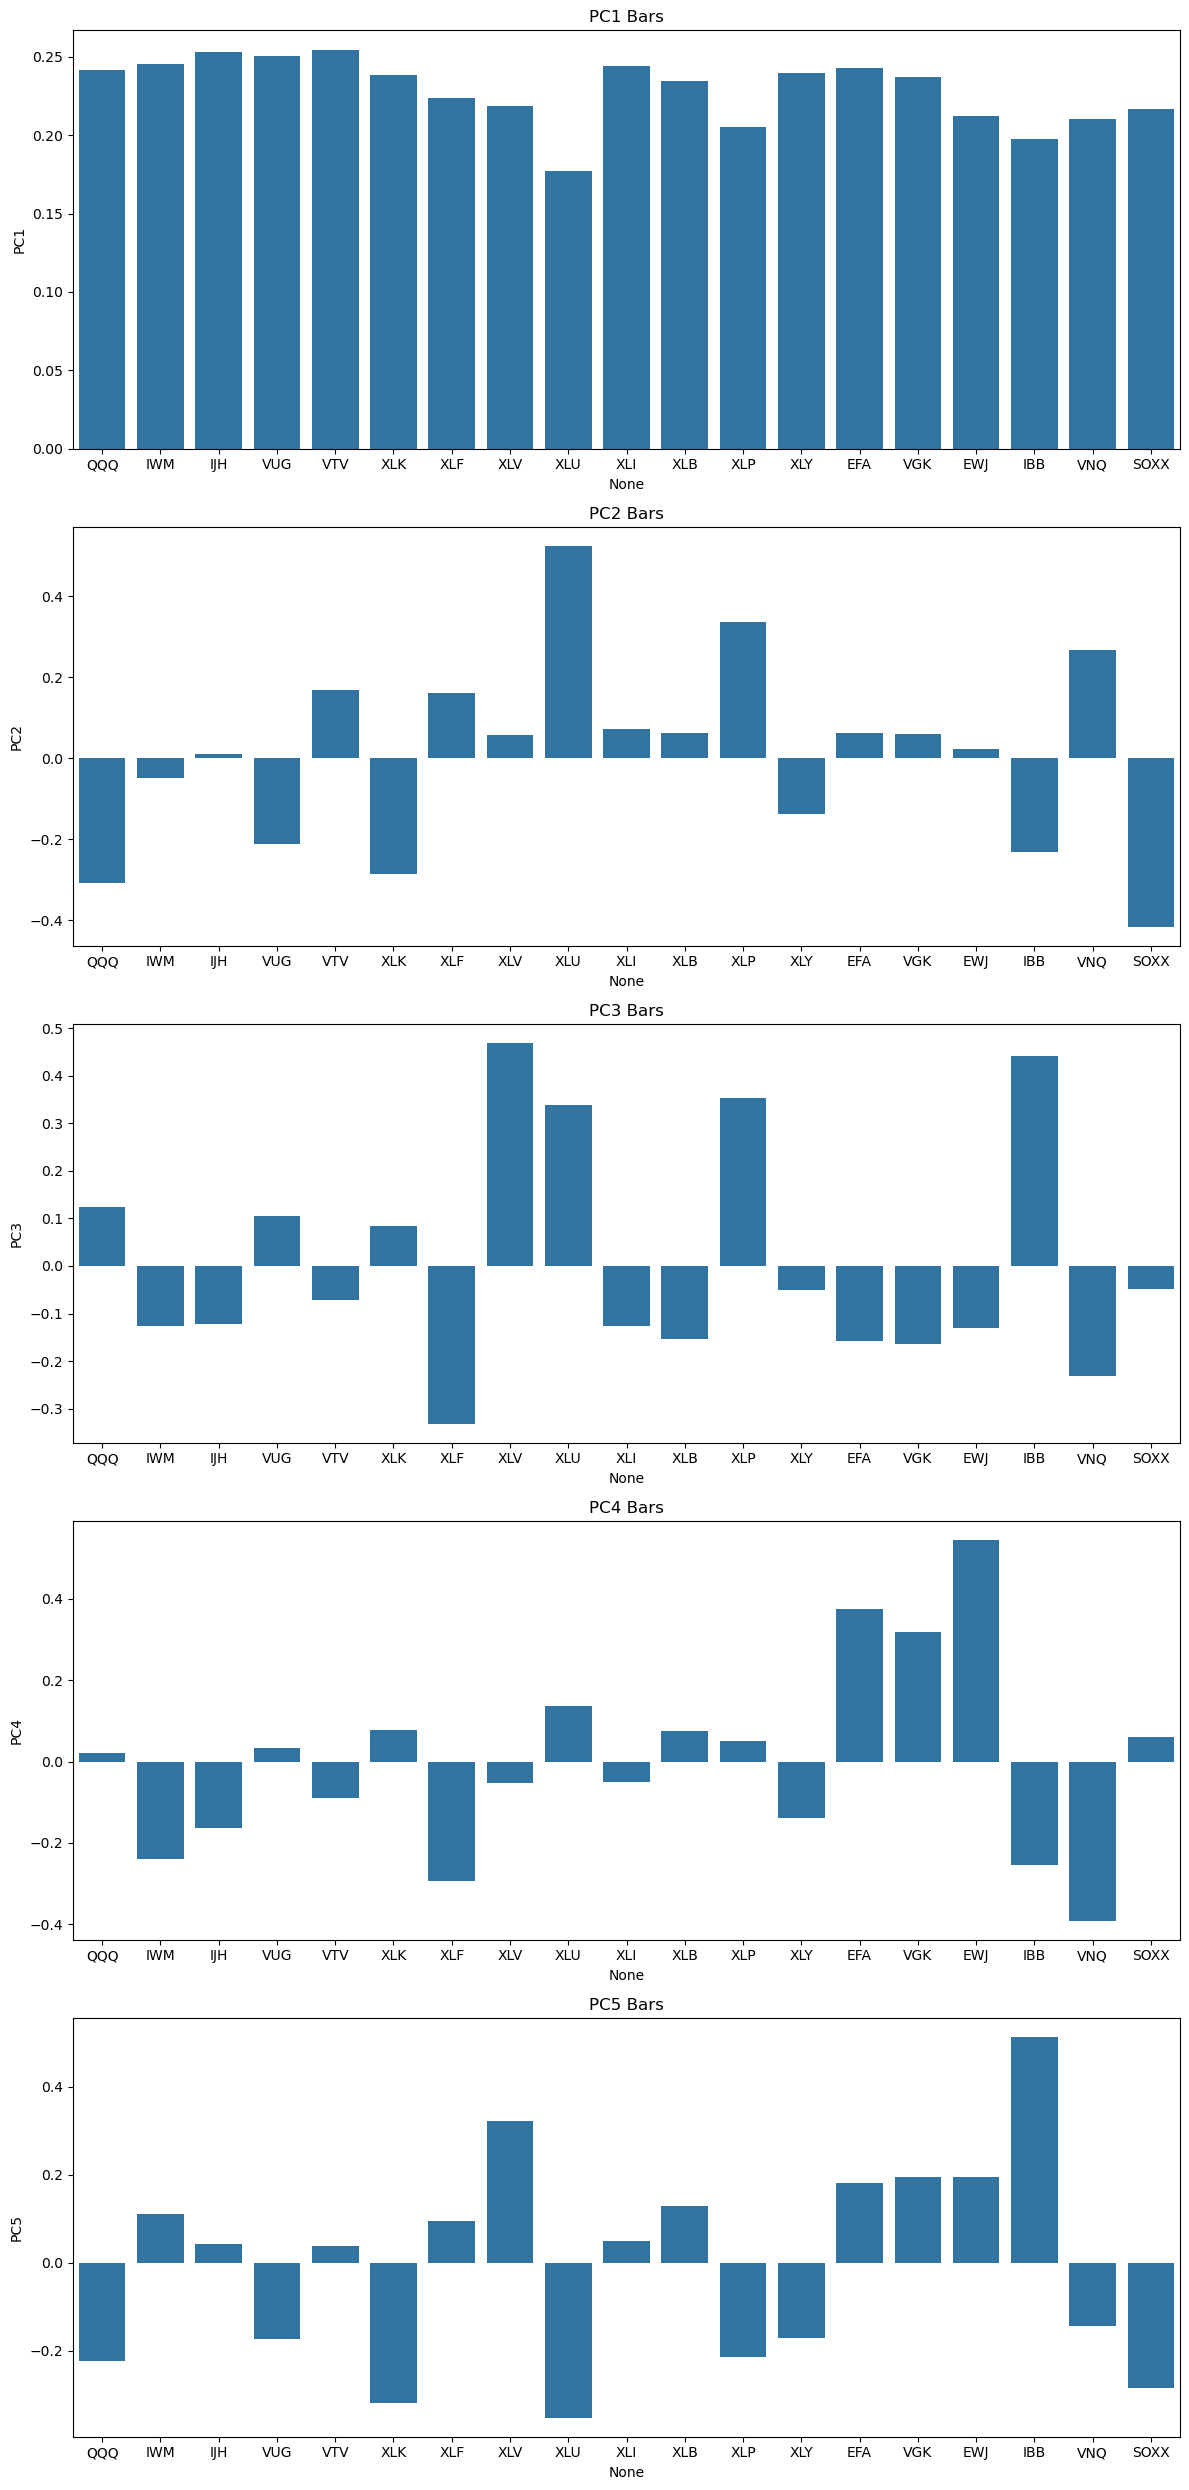

In [110]:
n_comp = pca.significant_components(p_comp)

pca_bars = plot.plot_pca_bars(loadings, n_comp)
os.makedirs('results/universe_selection', exist_ok = True)
pca_bars.savefig('results/universe_selection/pca_bars.png')

In [111]:
import pandas as pd

top_pcas = pca.top_pcas(loadings, n_comp)
top_pcas = correlation.correlation_check(top_pcas, matrix, loadings)
top_pcas.append('SPY')
top_pcas.append('GLD')
top_pcas = pd.DataFrame(top_pcas)
top_pcas.to_csv('results/universe_selection/final_assets.csv', index = False)